In [15]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent


import data_loader as data_loader
import visualization as viz
import analysis_features as af


RAW_DIR = PROJECT_ROOT / "Data"      # raw data
PROCESSED_DIR = "Processed_data" # output
FS = 50                        # sampling rate

print(f"Current Working Directory: {Path.cwd()}")
print(f"Project Root Detected:     {PROJECT_ROOT}")
print(f"Raw data path:             {RAW_DIR}")

os.makedirs(PROCESSED_DIR, exist_ok=True)

print(":)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current Working Directory: /Users/louinsleung/EEN210/Xiaoye_week3_code
Project Root Detected:     /Users/louinsleung/EEN210
Raw data path:             /Users/louinsleung/EEN210/Data
:)


In [2]:
# batch processing all csv files to parquet
print(f"batch processing from '{RAW_DIR}'.")

data_loader.batch_process(RAW_DIR, PROCESSED_DIR)

print("：）Done!")


batch processing from '/Users/louinsleung/EEN210/Data'.
Found 178 CSV files in /Users/louinsleung/EEN210/Data
[Skip] FallingForwards_p1_1_35sek_20260206_113359.parquet already exists.
[Skip] FallingForwards_p1_1_35sek_20260206_113359.csv already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.parquet already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.csv already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.parquet already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.csv already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.parquet already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.csv already exists.
[Skip] Falling_backwards_short_P1_1_20260213_101958.parquet already exists.
[Skip] Falling_backwards_short_P1_1_20260213_101958.csv already exists.
[Skip] Falling_backwards_short_P1_2_20260213_102216.parquet already exists.
[Skip] Falling_backwards_short_P1_2_20260213_102216.csv already exists.
[Skip] Falling_bac

# TSA

- loading data
- handling gaps and interpolation


In [3]:
# smoothing
PROCESSED_DIR = "Processed_data/long" 
files = glob.glob(os.path.join(PROCESSED_DIR, "*.parquet"))


data_dict = {}
for f in files:
    data_dict[os.path.basename(f)] = pd.read_parquet(f)

print(f"Loaded {len(data_dict)} files.")

# smoothing
smoothed_data = af.apply_lowpass_filter(data_dict, cutoff=15, fs=50)


Loaded 184 files.


# Event segmentation

In [4]:
print("\nStarting data segmentation on smoothed data...")
window_list, metadata_df = af.extract_window_segments(smoothed_data, window_s=2.0, step_s=1.0, fs=50)
print(f"Segmentation complete. Generated {len(window_list)} windows.")


Starting data segmentation on smoothed data...
Segmentation complete. Generated 3550 windows.


# Feature extraction
- Time-domain features: Mean, variance, standard deviation, skewness.
- Frequency-domain features: Spectral entropy, energy.
- `tsfresh`

In [5]:
import tsfresh
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters


df_long_format = af.build_tsfresh_long_format(window_list)

print("\nStarting parallel feature extraction (tsfresh)...")

extraction_settings = EfficientFCParameters()
X_extracted = extract_features(
    df_long_format,
    column_id='window_id',
    column_sort='time_step',
    default_fc_parameters=extraction_settings,
    impute_function=impute
)

print("\nExecuting scalable hypothesis testing for feature selection...")

y_target = metadata_df.set_index('window_id')['label']
X_selected = select_features(X_extracted, y_target)

smooth_feature_df = X_selected.copy()
smooth_feature_df["file"] = metadata_df["file"].values
smooth_feature_df["label"] = metadata_df["label"].values
smooth_feature_df["activity"] = metadata_df["activity"].values
smooth_feature_df["t_start"] = metadata_df["t_start"].values
smooth_feature_df["t_end"] = metadata_df["t_end"].values


print(f"Original extracted features dimension: {X_extracted.shape[1]}")
print(f"Selected features dimension after testing: {X_selected.shape[1]}")

print('\n')
print("\nClass distribution:")
print(smooth_feature_df["activity"].value_counts())
smooth_feature_df.head()



Starting parallel feature extraction (tsfresh)...


Feature Extraction: 100%|██████████| 30/30 [01:40<00:00,  3.36s/it]



Executing scalable hypothesis testing for feature selection...
Original extracted features dimension: 4662
Selected features dimension after testing: 1737



Class distribution:
activity
Fall-Background    1183
Standing            757
Walking             656
Stand-Sit           338
Sit-Stand           298
Running             162
Fall                156
Name: count, dtype: int64


,ay__range_count__max_1__min_-1,ax__number_crossing_m__m_0,az__number_crossing_m__m_1,ax__range_count__max_0__min_-1000000000000.0,ax__count_above__t_0,ax__range_count__max_1000000000000.0__min_0,ax__count_below__t_0,ay__number_crossing_m__m_1,az__range_count__max_1__min_-1,ay__number_crossing_m__m_-1,...,"gy__change_quantiles__f_agg_""mean""__isabs_False__qh_0.4__ql_0.2",gx__index_mass_quantile__q_0.2,"ax__cwt_coefficients__coeff_12__w_5__widths_(2, 5, 10, 20)","ax__fft_coefficient__attr_""imag""__coeff_22","gz__fft_coefficient__attr_""imag""__coeff_6",file,label,activity,t_start,t_end
0,100.0,0.0,0.0,100.0,0.00,0.0,1.00,0.0,100.0,0.0,...,-0.020191,0.21,-0.247497,0.009732,5.061365,Falling_backwards_short_P1_3_20260213_102542.p...,0,Fall-Background,1.493259,3.473259
1,100.0,0.0,0.0,100.0,0.00,0.0,1.00,0.0,100.0,0.0,...,0.036164,0.20,-0.243311,-0.017527,5.911242,Falling_backwards_short_P1_3_20260213_102542.p...,0,Fall-Background,2.493259,4.473259
2,100.0,0.0,0.0,100.0,0.00,0.0,1.00,0.0,100.0,0.0,...,0.021512,0.19,-0.243689,0.013198,-2.039492,Falling_backwards_short_P1_3_20260213_102542.p...,0,Fall-Background,3.493259,5.473259
3,100.0,0.0,0.0,100.0,0.00,0.0,1.00,0.0,100.0,0.0,...,-1.050971,0.19,-0.246210,0.097884,-10.663476,Falling_backwards_short_P1_3_20260213_102542.p...,0,Fall-Background,4.493259,6.473259
4,100.0,6.0,2.0,86.0,0.14,14.0,0.86,0.0,89.0,0.0,...,-0.957186,0.60,-0.261675,-3.545135,-158.025103,Falling_backwards_short_P1_3_20260213_102542.p...,1,Fall,5.493259,7.473259


In [6]:
smooth_feature_df.to_csv("Test2.csv", index=False)

# Feature Exploration

extract the top 10 features from `tsfresh` then combined with the basic features to train model further


In [7]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score, precision_score

In [8]:
csv_path = "Test2.csv"
df = pd.read_csv(csv_path)


y = df['label']
groups = df['file']
columns_to_drop = ['file', 'label', 'activity', 't_start', 't_end']
X = df.drop(columns=columns_to_drop)
print(f"{X.shape}")
print(f"\n{y.value_counts()}")

(3550, 1737)

label
0    3394
1     156
Name: count, dtype: int64


In [9]:
sgkf = StratifiedGroupKFold(n_splits=5)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,      
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

y_true_all = []
y_pred_all = []
y_prob_all = []

In [11]:
for i, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]
    
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    y_prob_all.extend(y_prob)
    
    cm_fold = confusion_matrix(y_test, y_pred, labels=[0, 1])
    
    if sum(y_test) > 0:
        fold_recall = cm_fold[1, 1] / (cm_fold[1, 0] + cm_fold[1, 1])
        print(f"Fold {i+1} Recall: {fold_recall:.4f}")
        print(f" Train: Fall={y.iloc[train_idx].sum()}, Total={len(train_idx)}")
        print(f" Test:  Fall={y_test.sum()}, Total={len(test_idx)}")
        print('\n')
    else:
        print(f"Fold {i+1} Recall: N/A")

Fold 1 Recall: 0.8387
 Train: Fall=125, Total=2837
 Test:  Fall=31, Total=713


Fold 2 Recall: 0.8438
 Train: Fall=124, Total=2843
 Test:  Fall=32, Total=707


Fold 3 Recall: 0.9032
 Train: Fall=125, Total=2838
 Test:  Fall=31, Total=712


Fold 4 Recall: 0.9000
 Train: Fall=126, Total=2843
 Test:  Fall=30, Total=707


Fold 5 Recall: 0.9688
 Train: Fall=124, Total=2839
 Test:  Fall=32, Total=711




              precision    recall  f1-score   support

Non-fall (0)     0.9950    0.9900    0.9925      6788
    Fall (1)     0.8035    0.8910    0.8450       312

    accuracy                         0.9856      7100
   macro avg     0.8992    0.9405    0.9187      7100
weighted avg     0.9866    0.9856    0.9860      7100



Text(47.722222222222214, 0.5, 'True Label')

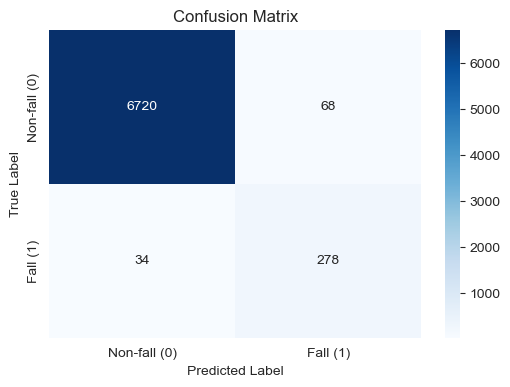

In [12]:
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


print(classification_report(y_true_all, y_pred_all, target_names=['Non-fall (0)', 'Fall (1)'], digits=4))


cm_global = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-fall (0)', 'Fall (1)'],
            yticklabels=['Non-fall (0)', 'Fall (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

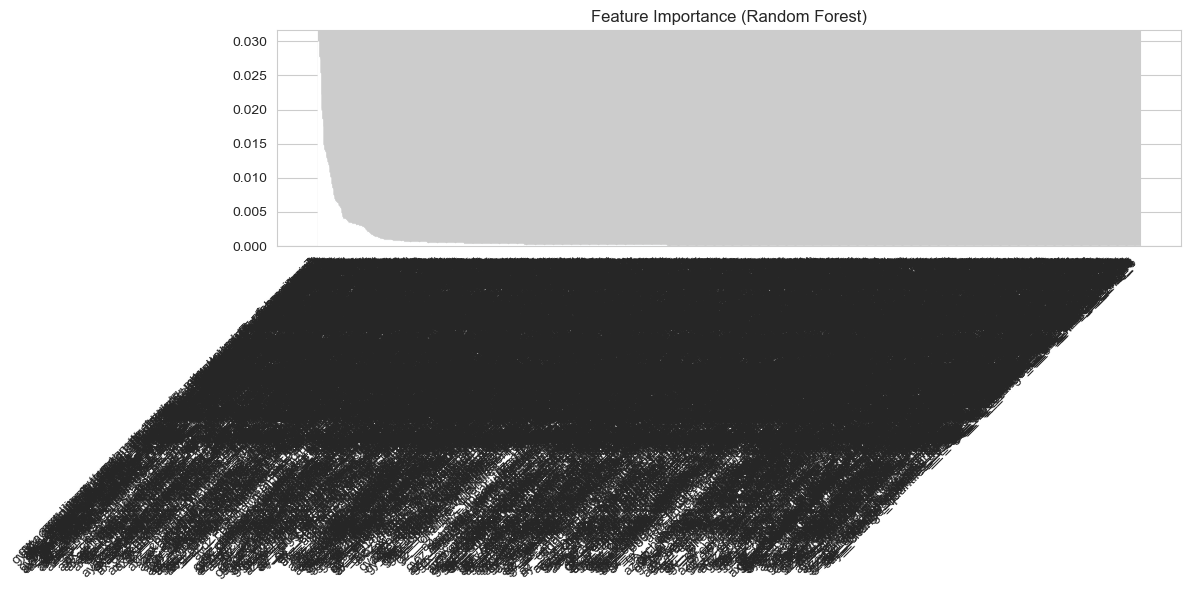


Top 10 important features:
1. gy__abs_energy (0.0301)
2. gy__mean_n_absolute_max__number_of_maxima_7 (0.0277)
3. gy__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"min" (0.0275)
4. ax__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"max" (0.0254)
5. gy__variance (0.0223)
6. gy__minimum (0.0202)
7. gy__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"min" (0.0200)
8. gy__standard_deviation (0.0186)
9. gy__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"mean" (0.0185)
10. az__cid_ce__normalize_False (0.0176)


In [13]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("\nTop 10 important features:")
for i in range(10):
    print(f"{i+1}. {X.columns[indices[i]]} ({importances[indices[i]]:.4f})")

# Model

use 20 features to train model to improve prediction efficiency

In [19]:
print("Extracting features from windows...")
rows = []
for w in window_list:
    rows.append(af.extract_features_from_window(w, fs=FS))

X_final = pd.DataFrame(rows).fillna(0.0)
y_final = metadata_df["label"].values
groups_final = metadata_df["file"].values


df2 = X_final.copy()
df2["file"]     = metadata_df["file"].values
df2["label"]    = metadata_df["label"].values
df2["activity"] = metadata_df["activity"].values
df2["t_start"]  = metadata_df["t_start"].values
df2["t_end"]    = metadata_df["t_end"].values

print(f"Feature count: {X_final.shape[1]}")  
print(f'Window count: {X_final.shape[0]}')
print('\nActivity distribution:')
print(df2["activity"].value_counts())

Extracting features from windows...
Feature count: 20
Window count: 3550

Activity distribution:
activity
Fall-Background    1183
Standing            757
Walking             656
Stand-Sit           338
Sit-Stand           298
Running             162
Fall                156
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score

In [20]:
models = {
    "Standard RF":      RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1),
    "Balanced RF":      BalancedRandomForestClassifier(n_estimators=200, max_depth=6, sampling_strategy='all', replacement=False, bootstrap=True, random_state=42, n_jobs=-1),
    "SMOTE + RF":       ImbPipeline([
                            ('smote', SMOTE(random_state=42)),
                            ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1))
                        ]),
}

results_final = {}

for name, model in models.items():
    y_true_all, y_pred_all, y_prob_all = [], [], []

    for train_idx, test_idx in sgkf.split(X_final, y_final, groups=groups_final):
        X_tr, X_te = X_final.iloc[train_idx], X_final.iloc[test_idx]
        y_tr, y_te = y_final[train_idx],      y_final[test_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)
        y_prob_all.extend(y_prob)

    results_final[name] = (y_true_all, y_pred_all, y_prob_all)
    print(f"\n[{name}]")
    print(classification_report(y_true_all, y_pred_all, target_names=["Non-Fall", "Fall"]))
    print(f"PR-AUC: {average_precision_score(y_true_all, y_prob_all):.4f}")
    print(f'Accuracy: {np.mean(np.array(y_true_all) == np.array(y_pred_all)):.4f}')
    


[Standard RF]
              precision    recall  f1-score   support

    Non-Fall       0.99      0.99      0.99      3394
        Fall       0.75      0.86      0.80       156

    accuracy                           0.98      3550
   macro avg       0.87      0.92      0.90      3550
weighted avg       0.98      0.98      0.98      3550

PR-AUC: 0.8787
Accuracy: 0.9814

[Balanced RF]
              precision    recall  f1-score   support

    Non-Fall       1.00      0.96      0.98      3394
        Fall       0.50      0.94      0.65       156

    accuracy                           0.96      3550
   macro avg       0.75      0.95      0.81      3550
weighted avg       0.98      0.96      0.96      3550

PR-AUC: 0.8734
Accuracy: 0.9555

[SMOTE + RF]
              precision    recall  f1-score   support

    Non-Fall       0.99      0.98      0.99      3394
        Fall       0.68      0.89      0.77       156

    accuracy                           0.98      3550
   macro avg       0

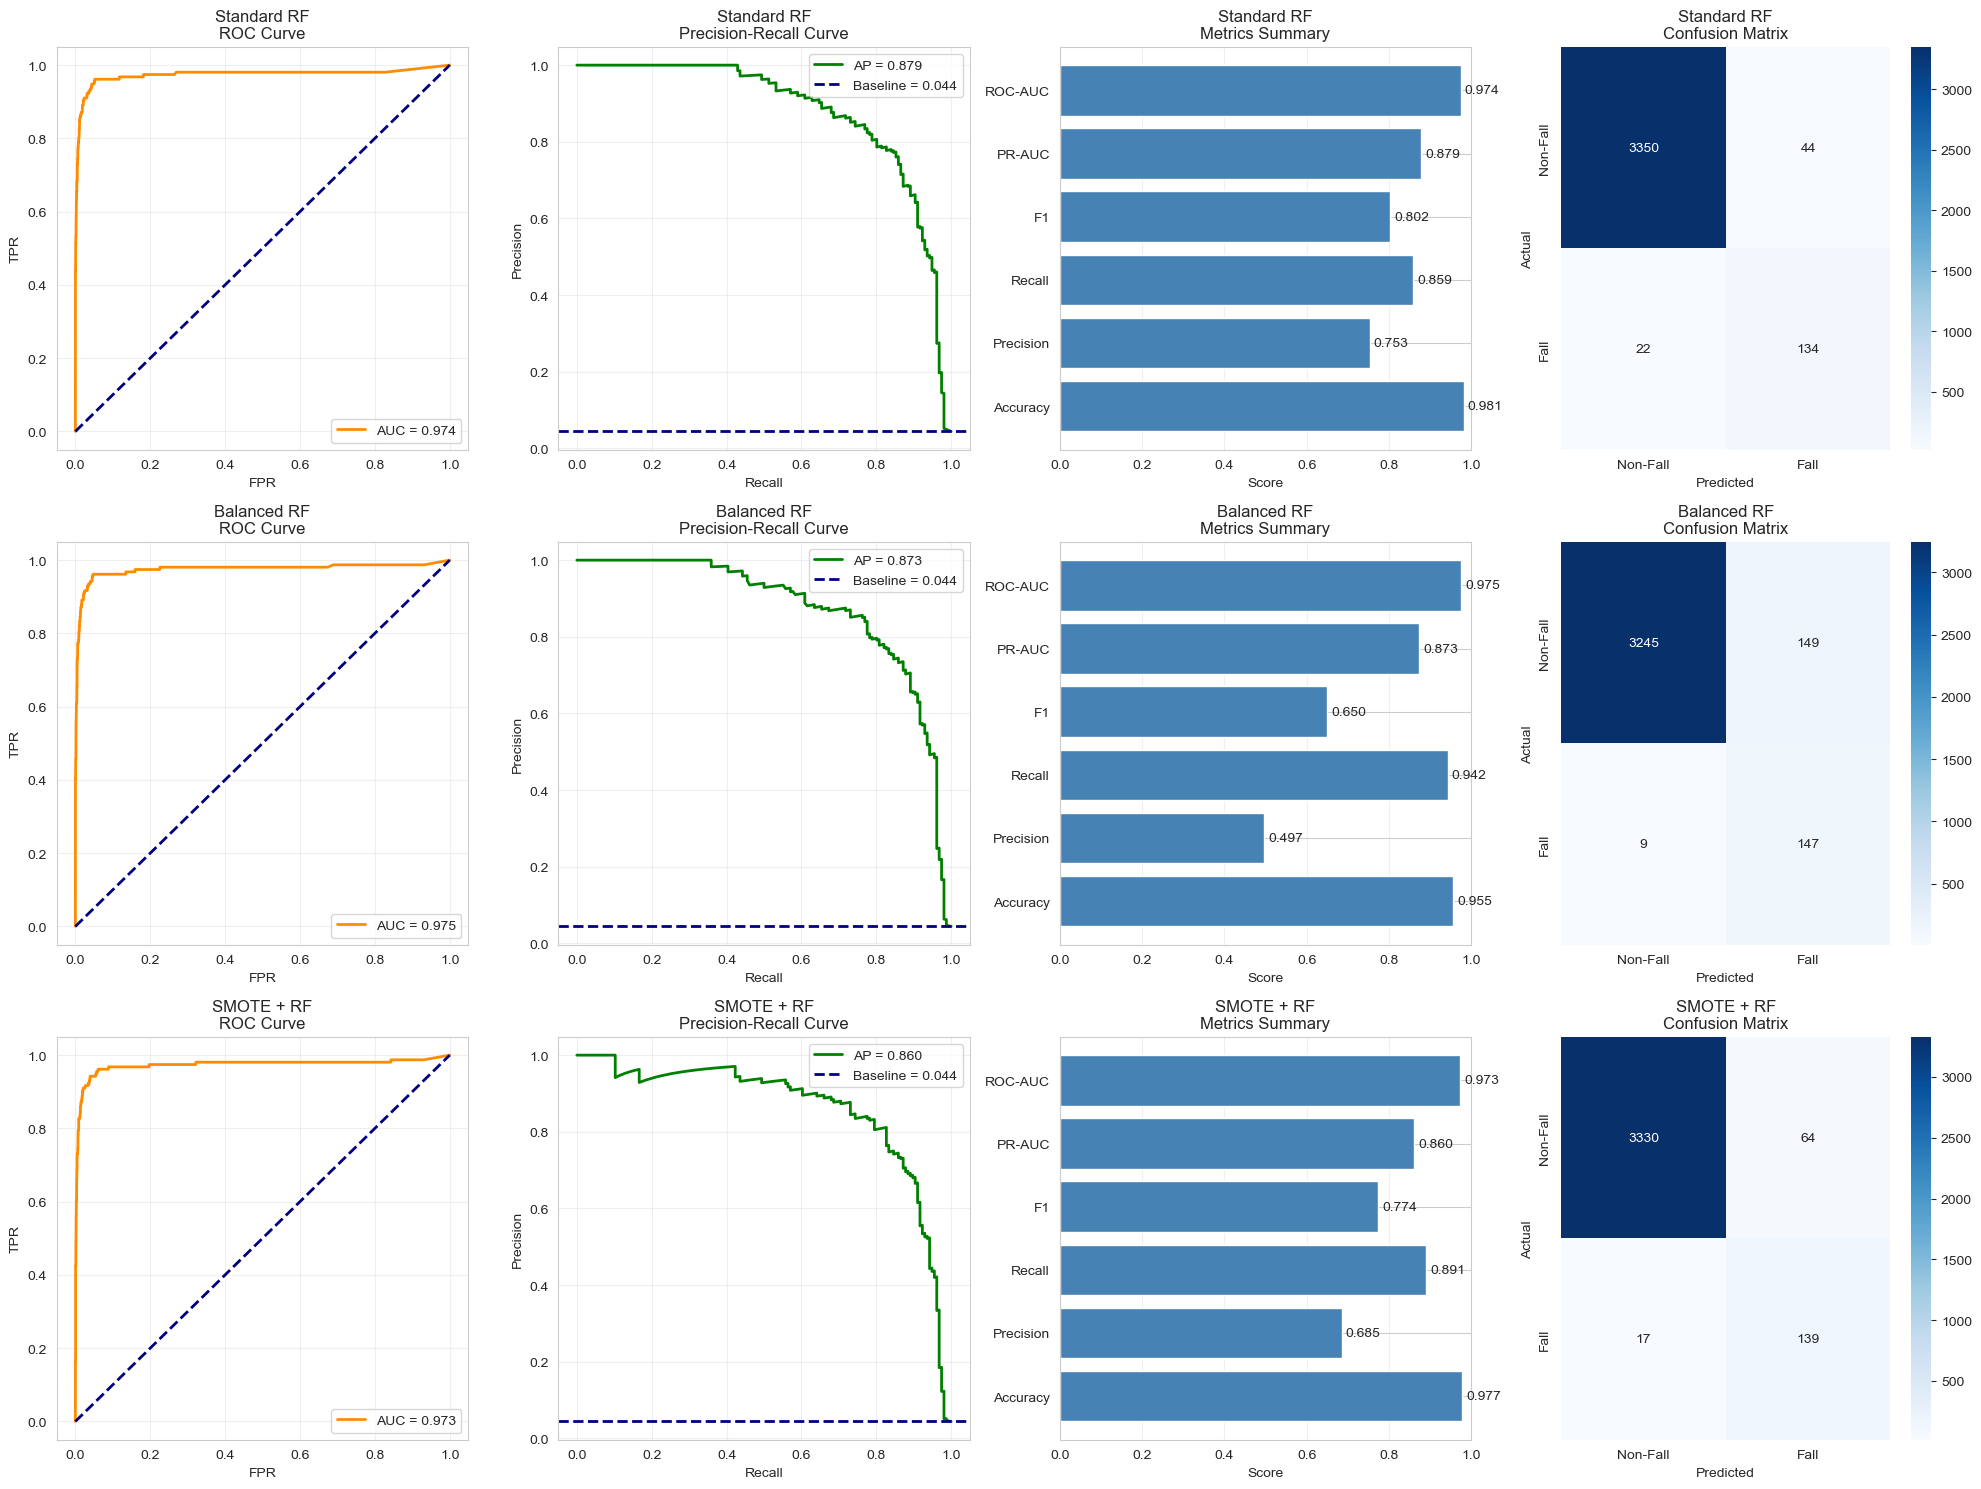

In [21]:
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix)

fig, axes = plt.subplots(len(results_final), 4, figsize=(20, 5 * len(results_final)))

for row_idx, (name, (yt, yp, ypr)) in enumerate(results_final.items()):
    yt, yp, ypr = np.array(yt), np.array(yp), np.array(ypr)
    ax_roc, ax_pr, ax_acc, ax_cm = axes[row_idx]

    # ROC
    fpr, tpr, _ = roc_curve(yt, ypr)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax_roc.plot([0, 1], [0, 1], 'navy', lw=2, linestyle='--')
    ax_roc.set(title=f'{name}\nROC Curve', xlabel='FPR', ylabel='TPR')
    ax_roc.legend(loc='lower right')
    ax_roc.grid(True, alpha=0.3)

    # precision-recall
    precision, recall, _ = precision_recall_curve(yt, ypr)
    pr_auc = average_precision_score(yt, ypr)
    baseline = yt.sum() / len(yt)
    ax_pr.plot(recall, precision, color='green', lw=2, label=f'AP = {pr_auc:.3f}')
    ax_pr.axhline(baseline, color='navy', lw=2, linestyle='--', label=f'Baseline = {baseline:.3f}')
    ax_pr.set(title=f'{name}\nPrecision-Recall Curve', xlabel='Recall', ylabel='Precision')
    ax_pr.legend(loc='upper right')
    ax_pr.grid(True, alpha=0.3)

    # accuracy & other metrics
    cm = confusion_matrix(yt, yp)
    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
    metrics = {
        'Accuracy':  accuracy,
        'Precision': precision_score(yt, yp),
        'Recall':    recall_score(yt, yp),
        'F1':        f1_score(yt, yp),
        'PR-AUC':    pr_auc,
        'ROC-AUC':   roc_auc,
    }
    ax_acc.barh(list(metrics.keys()), list(metrics.values()), color='steelblue')
    ax_acc.set_xlim(0, 1)
    ax_acc.set(title=f'{name}\nMetrics Summary', xlabel='Score')
    for i, (k, v) in enumerate(metrics.items()):
        ax_acc.text(v + 0.01, i, f'{v:.3f}', va='center')
    ax_acc.grid(True, alpha=0.3, axis='x')

    # ── Confusion Matrix ─────────────────────────────────
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Non-Fall', 'Fall'],
                yticklabels=['Non-Fall', 'Fall'])
    ax_cm.set(title=f'{name}\nConfusion Matrix',
              xlabel='Predicted', ylabel='Actual')

plt.tight_layout()
plt.show()

At Recall ≥ 0.9: threshold=0.254, Precision=0.662


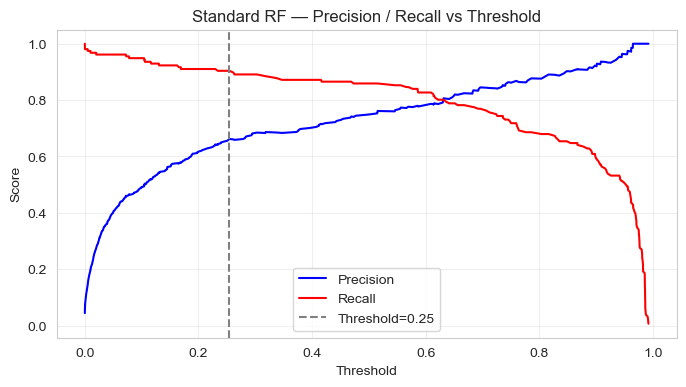

In [22]:

yt  = np.array(results_final["Standard RF"][0])
ypr = np.array(results_final["Standard RF"][2])

precision_c, recall_c, thresholds = precision_recall_curve(yt, ypr)


target_recall = 0.90
valid = recall_c[:-1] >= target_recall
if valid.any():
    best_idx = np.argmax(precision_c[:-1][valid])
    best_threshold = thresholds[valid][best_idx]
    print(f"At Recall ≥ {target_recall}: threshold={best_threshold:.3f}, "
          f"Precision={precision_c[:-1][valid][best_idx]:.3f}")
else:
    print("No threshold achieves target recall")


plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision_c[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall_c[:-1],    label='Recall',    color='red')
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Standard RF — Precision / Recall vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
import joblib

final_model = models["Standard RF"]
final_model.fit(X_final, y_final) 
bundle = {"model": final_model, "feature_cols": list(X_final.columns)}
joblib.dump(bundle, "Mar05_model.joblib")
print("Saved model bundle with feature columns:", len(bundle["feature_cols"]))

Saved model bundle with feature columns: 20
